In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI & ML/Week5/Copy of FruitinAmazon.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed successfully")

Extraction completed successfully


Identifying dataset classes

In [4]:
train_dir = "dataset/FruitinAmazon/train"

#getting the class name/subdirectories
class_names = sorted(os.listdir(train_dir))

print("Dataset name: ",os.listdir("dataset"))

if not class_names:
  print("No class directories foiunf in the train folder!!")
else:
  print("Class names:",class_names)



Dataset name:  ['FruitinAmazon']
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Visualizing sample images

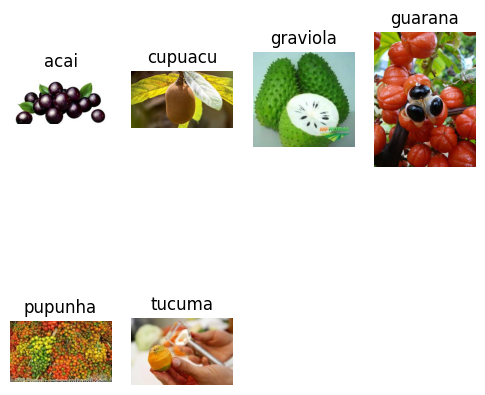

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(os.listdir(train_dir))

plt.figure(figsize=(6,6))
#this is to display one random image from each class
for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

The dataset contains images grouped into class folders. Each folder represents a fruit category. The images vary in orientation, lighting, and background but share common visual features that help the CNN learn patterns.

In [6]:
from PIL import Image,UnidentifiedImageError

corrupted_images = [] #list to store all the corrupted images
#looping through each class folder and cheking for the corrupted images
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir,class_name)
    if os.path.isdir(class_path):  #ensuring it is a valid directory
      images = os.listdir(class_path)
      for file in os.listdir(class_path):
        image_path = os.path.join(class_path,file)
        try:
            with Image.open(image_path) as img:
              img.verify() #verifying if image can be opened correctly

        except (IOError, UnidentifiedImageError):

                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if corrupted_images:
    print("Corrupted images found:")
    for img in corrupted_images:
        print(img)
else:
  print("No corrupted images found.")

No corrupted images found.


Checking class imbalance

In [7]:
#dictionary to store the number of images in each class
class_counts = {}

for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png','.jpg','jpeg'))]
    class_counts[class_name] = len(images) #counts images in each class

#printing class imbalance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid image count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("="* 45)


Class Distribution:
Class Name               Valid image count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


Random Image Selection

In [8]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)

Random image Plot


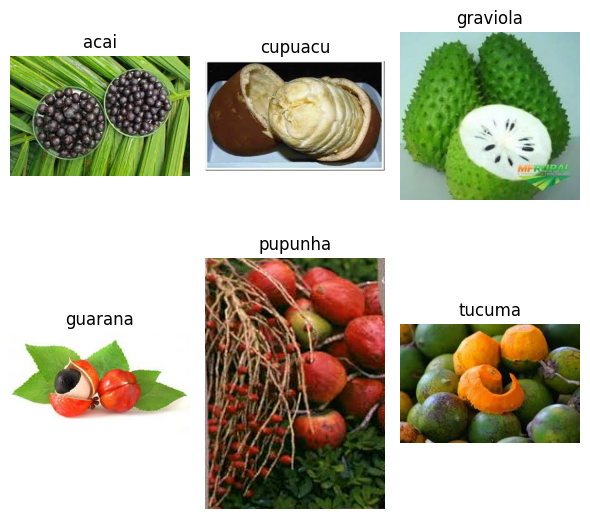

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

Data loading and preprocessing

In [10]:
import tensorflow as tf

img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2
#normalizing pixel values from 0-255 to 0-1
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
#loading validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
#applying normalization to datasets
train_ds = train_ds.map(lambda x,y:(rescale(x),y))
val_ds = val_ds.map(lambda x,y:(rescale(x),y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Data Augmentation

In [17]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(factor=0.2)
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

CNN model Task 1

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Lambda,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling2D
)

# Build CNN model
model = Sequential([
    # Input layer
    Input(shape=(224, 224, 3)),

    # Normalize pixel values from 0-255 to 0-1
    Lambda(lambda x: x / 255.0),

    # 1st convolution block
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 2nd convolution block
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 3rd convolution block
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    # 4th convolution block
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    # Reduce feature maps to one value per channel
    GlobalAveragePooling2D(),

    # Fully connected layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Output layer
    Dense(len(class_names), activation='softmax')
])



In [23]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_4 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           77

 Total params: 424,518 (1.62 MB)

 Trainable params: 423,302 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [24]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [25]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model during training
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Stop training if validation loss does not improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2037 - loss: 2.6801
Epoch 1: val_loss improved from None to 1.79327, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 6s/step - accuracy: 0.2361 - loss: 2.5480 - val_accuracy: 0.0000e+00 - val_loss: 1.7933
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3953 - loss: 1.5529
Epoch 2: val_loss improved from 1.79327 to 1.79076, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.3889 - loss: 1.5975 - val_accuracy: 0.0000e+00 - val_loss: 1.7908
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4444 - loss: 1.7247
Epoch 3: val_loss did not improve from 1.79076
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.4583 - loss: 1.7184 - val_accuracy: 0.1667 - val_loss: 1.7933
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5093 - loss: 1.3392
Epoch 4: va

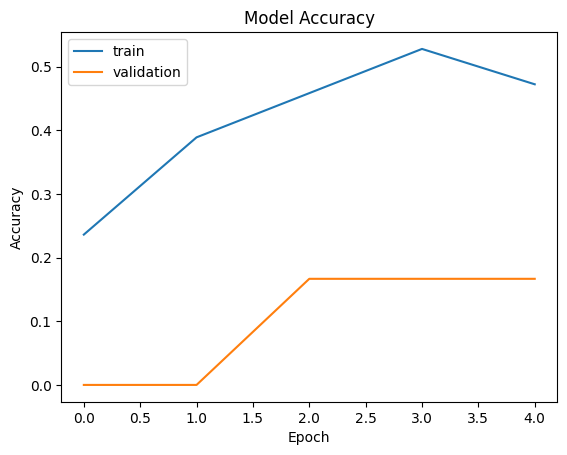

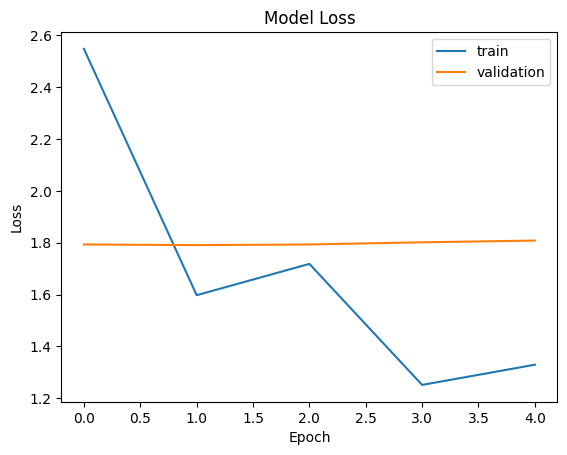

In [26]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='validation')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='validation')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#Key observations:

Training improving,
Validation stuck,
Accuracy very low (~17%),
Loss not decreasing

In [27]:
test_loss,test_acc = model.evaluate(val_ds)

print("Test Accuracy:",test_acc)
print("Test Loss:",test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step - accuracy: 0.0000e+00 - loss: 1.7908
Test Accuracy: 0.0
Test Loss: 1.7907557487487793


In [29]:
# Save the trained model
model.save("fruit_cnn_model.keras")

# Load the saved model
from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_cnn_model.keras", safe_mode=False)

# Evaluate the loaded model
loss, accuracy = loaded_model.evaluate(val_ds)

print("Loaded Model Accuracy:", accuracy)
print("Loaded Model Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 1.7908
Loaded Model Accuracy: 0.0
Loaded Model Loss: 1.7907557487487793


In [30]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images,labels in val_ds:

    predictions = loaded_model.predict(images)

    pred_labels = np.argmax(predictions,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)
unique_labels = np.unique(y_true)

print(classification_report(y_true,y_pred, labels=unique_labels,target_names=[classes[i] for i in unique_labels]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
              precision    recall  f1-score   support

     pupunha       0.00      0.00      0.00       3.0
      tucuma       0.00      0.00      0.00      15.0

   micro avg       0.00      0.00      0.00      18.0
   macro avg       0.00      0.00      0.00      18.0
weighted avg       0.00      0.00      0.00      18.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# Transfer Learning (VGG16)

In [31]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

Load Pretrained VGG16 Model

In [32]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze pretrained layers

In [33]:
for layer in base_model.layers:
    layer.trainable = False

Build Transfer Learning Model

In [34]:
model_transfer = Sequential([

    base_model,

    Flatten(),

    Dense(256, activation='relu'),

    Dense(len(class_names), activation='softmax')
])

Compile the Model

In [35]:
model_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train the Model

In [37]:
history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 61s 20s/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 0.8889 - val_loss: 0.3587
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 19s/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 0.9444 - val_loss: 0.2931
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 20s/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9444 - val_loss: 0.2542
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 19s/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9444 - val_loss: 0.2299
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 19s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9444 - val_loss: 0.2157
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 18s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9444 - val_loss: 0.2083
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 19s/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9444 - val_loss: 0.2060
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 18s/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9444 - val_loss: 0.2075


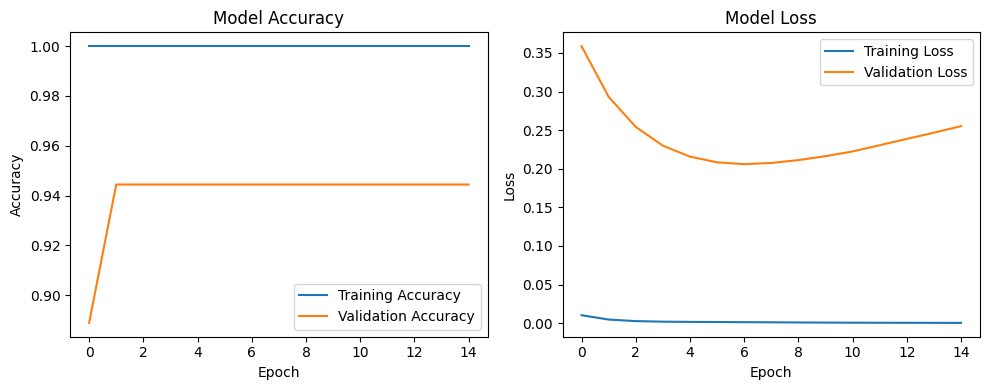

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The model achieves high accuracy (~94%) and generalizes well. Although slight overfitting is observed after a few epochs, the overall performance is strong

Evaluate the Model

In [39]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Transfer Learning Accuracy:", accuracy)
print("Transfer Learning Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.9444 - loss: 0.2552
Transfer Learning Accuracy: 0.9444444179534912
Transfer Learning Loss: 0.255160927772522


In [44]:
model_transfer.save("final_model.keras")

# Fine-Tuning

In [40]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

Recompile with smaller learning rate

In [41]:
from tensorflow.keras.optimizers import RMSprop

model_transfer.compile(
    optimizer=RMSprop(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Fine-Tuned Model

In [42]:
history_finetune = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 19s/step - accuracy: 1.0000 - loss: 3.6715e-04 - val_accuracy: 0.9444 - val_loss: 0.2592
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 18s/step - accuracy: 1.0000 - loss: 3.5789e-04 - val_accuracy: 0.9444 - val_loss: 0.2617
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 19s/step - accuracy: 1.0000 - loss: 3.5031e-04 - val_accuracy: 0.9444 - val_loss: 0.2649
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 18s/step - accuracy: 1.0000 - loss: 3.4266e-04 - val_accuracy: 0.9444 - val_loss: 0.2685
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 19s/step - accuracy: 1.0000 - loss: 3.3520e-04 - val_accuracy: 0.8889 - val_loss: 0.2701
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 18s/step - accuracy: 1.0000 - loss: 3.3014e-04 - val_accuracy: 0.8889 - val_loss: 0.2741
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 19s/step - accuracy: 1.0000 - loss: 3.2316e-04 - val_accuracy: 0.8889 - val_loss: 0.2754
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 19s/step - accuracy: 1.0000 - loss: 3.1937e-04 - val_accu

Final Evaluation

In [43]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Fine-Tuned Model Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.8889 - loss: 0.2813
Fine-Tuned Model Accuracy: 0.8888888955116272


# Final Conclusion:
# The transfer learning model achieved high accuracy (~94.44%) and performed well on validation data.
# Fine-tuning the model slightly reduced the accuracy (~88.89%) due to the small dataset size.
# Therefore, the transfer learning model without fine-tuning is selected as the final model.